In [1]:
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 16.4 MB/s eta 0:00:0031m12.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.1/447.1 kB 20.0 MB/s eta 0:00:00


In [2]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU (M1/M2/M3)
    print("Using device: MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: MPS (Apple GPU)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from torch.utils.data import random_split

import torch.nn.functional as F
from torchvision.transforms.functional import InterpolationMode

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

from torch.cuda.amp import autocast, GradScaler

/Users/youshodeepacharya/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class DiabetMessidorEyePac(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [3]:
dataset = DiabetMessidorEyePac("/Users/youshodeepacharya/Downloads/IMG_CLASSES")

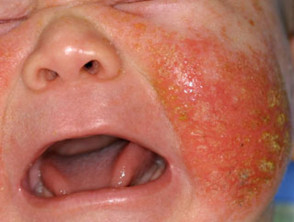

In [4]:
image , label = dataset[1]
image 

In [5]:
print(label)


0


In [6]:
data_dir = "/Users/youshodeepacharya/Downloads/IMG_CLASSES"
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}

In [7]:
print(target_to_class)

{0: '1. Eczema 1677', 1: '10. Warts Molluscum and other Viral Infections - 2103', 2: '2. Melanoma 15.75k', 3: '3. Atopic Dermatitis - 1.25k', 4: '4. Basal Cell Carcinoma (BCC) 3323', 5: '5. Melanocytic Nevi (NV) - 7970', 6: '6. Benign Keratosis-like Lesions (BKL) 2624', 7: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 8: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 9: '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k'}


In [8]:
transform = transforms.Compose([
      transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = DiabetMessidorEyePac(data_dir , transform=transform)

In [9]:
image, label = dataset[100]
image.shape

torch.Size([3, 224, 224])

In [10]:
# iterate over dataset
for image, label in dataset:
    break

In [11]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [12]:
for images, labels in dataloader:
    break

In [13]:
images.shape, labels.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

In [14]:
labels

tensor([3, 4, 1, 2, 0, 0, 7, 4, 0, 8, 4, 0, 8, 5, 5, 2])

In [15]:
class DiabetModel(nn.Module):
    def __init__(self , num_classes = 10):
        super(DiabetModel,self).__init__()
        self.base_model = timm.create_model('efficientnet_b4', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])
        
        out_size = 1792 
        self.classifier = nn.Sequential(
            nn.Flatten(),nn.Dropout(0.3),nn.Linear(out_size , num_classes)
        ) 
        
        
    def forward(self , x) : 
        x= self.features(x)
        output = self.classifier(x)
        return output

In [16]:
class DiabeticModel2(nn.Module): 
    def __init__(self, num_classes=10):
        super(DiabeticModel2, self).__init__()
        # Define the layers of the model
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)  # Increased dropout

    def forward(self, x):
        # Apply convolutions, followed by batch normalization, activation, and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # Flatten the tensor for the fully connected layer
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [18]:
model1 = DiabetModel(num_classes=10)
model2 = DiabeticModel2(num_classes=10)

In [19]:
criterion1 = nn.CrossEntropyLoss().to(device)
optimizer1 = optim.Adam(model1.parameters() , lr = 0.001)
criterion2 = nn.CrossEntropyLoss().to(device)
optimizer2 = optim.Adam(model2.parameters() , lr = 0.001)

In [20]:
# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create the data loaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
from tqdm import tqdm  # simple, no notebook widgets

model2.to(device)
num_epochs = 5

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # ------------------ TRAIN ------------------
    model2.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    print(f"\nEpoch {epoch+1}/{num_epochs} - Training")
    for images, labels in tqdm(train_loader, desc="Training Loop"):
        images, labels = images.to(device), labels.to(device)

        optimizer2.zero_grad()

        # ❌ no AMP on CPU, just normal forward
        output = model2(images)
        loss = criterion2(output, labels)

        loss.backward()
        optimizer2.step()

        # stats
        _, predicted = torch.max(output, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)

    # ------------------ VALIDATION ------------------
    model2.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0

    print(f"Epoch {epoch+1}/{num_epochs} - Validation")
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation Loop"):
            images, labels = images.to(device), labels.to(device)

            output = model2(images)
            loss = criterion2(output, labels)

            _, predicted = torch.max(output, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_losses.append(val_loss)

    print(f"""
Epoch {epoch+1}/{num_epochs} :
  Train loss      : {train_loss:.4f}
  Train accuracy  : {train_accuracy:.4f}
  Val loss        : {val_loss:.4f}
  Val accuracy    : {val_accuracy:.4f}
""")


Epoch 1/5 - Training


Training Loop: 100%|██████████████████████████| 679/679 [06:51<00:00,  1.65it/s]


Epoch 1/5 - Validation


Validation Loop: 100%|████████████████████████| 170/170 [00:54<00:00,  3.14it/s]



Epoch 1/5 :
  Train loss      : 1.2685
  Train accuracy  : 0.5312
  Val loss        : 1.0501
  Val accuracy    : 0.5923


Epoch 2/5 - Training


...


Epoch 4/5 :
  Train loss      : 0.8671
  Train accuracy  : 0.6702
  Val loss        : 0.8946
  Val accuracy    : 0.6601


Epoch 5/5 - Training


Training Loop: 100%|██████████████████████████| 679/679 [06:52<00:00,  1.65it/s]


Epoch 5/5 - Validation


Validation Loop: 100%|████████████████████████| 170/170 [00:54<00:00,  3.14it/s]


Epoch 5/5 :
  Train loss      : 0.7807
  Train accuracy  : 0.7042
  Val loss        : 0.8818
  Val accuracy    : 0.6756



In [1]:
import torch
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

NameError: name 'device' is not defined

In [2]:
# ==========================================
# 1. Imports
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
import timm
from torch.amp import autocast, GradScaler

# ==========================================
# 2. Device selection (CPU / CUDA / MPS)
# ==========================================
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

# ==========================================
# 3. Dataset & DataLoaders
# ==========================================
# 🔁 Change this path if needed
data_dir = "/Users/youshodeepacharya/Downloads/IMG_CLASSES"

# Transforms (match EfficientNet/ImageNet)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# ImageFolder dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)
print("Found classes:", class_names)

# Train/val split (80/20)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# DataLoaders (batch size tuned for Mac)
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)

# ==========================================
# 4. EfficientNet-B0 Model (lighter + frozen backbone)
# ==========================================
class DiabetModel(nn.Module):
    def __init__(self, num_classes=10, freeze_backbone=True):
        super(DiabetModel, self).__init__()
        
        # Smaller & faster EfficientNet
        self.base_model = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=num_classes   # timm will create classifier layer for us
        )
        
        if freeze_backbone:
            # Freeze all except classifier
            for name, param in self.base_model.named_parameters():
                if "classifier" not in name:
                    param.requires_grad = False

    def forward(self, x):
        return self.base_model(x)

model1 = DiabetModel(num_classes=num_classes, freeze_backbone=True).to(device)

# Only train parameters that require grad (mostly classifier head)
optimizer1 = optim.Adam(
    filter(lambda p: p.requires_grad, model1.parameters()),
    lr=1e-3
)
criterion1 = nn.CrossEntropyLoss().to(device)

# ==========================================
# 5. Training Loop with AMP (on MPS/CUDA)
# ==========================================
num_epochs = 5
train_losses, val_losses = [], []

use_amp = device.type in ["cuda", "mps"]
# 🔧 FIXED: no device_type arg here for your PyTorch version
scaler = GradScaler() if use_amp else None
print("AMP enabled:", use_amp)

for epoch in range(num_epochs):
    # ------------------ TRAIN ------------------
    model1.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    print(f"\nEpoch {epoch+1}/{num_epochs} - Training")
    for images, labels in tqdm(train_loader, desc="Training Loop"):
        images, labels = images.to(device), labels.to(device)
        optimizer1.zero_grad()

        # Forward with/without AMP
        if use_amp:
            with autocast(device_type=device.type, dtype=torch.float16):
                outputs = model1(images)
                loss = criterion1(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer1)
            scaler.update()
        else:
            outputs = model1(images)
            loss = criterion1(outputs, labels)
            loss.backward()
            optimizer1.step()

        # Stats
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)

    # ------------------ VALIDATION ------------------
    model1.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0
    true_labels = []
    predicted_labels = []

    print(f"Epoch {epoch+1}/{num_epochs} - Validation")
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation Loop"):
            images, labels = images.to(device), labels.to(device)

            outputs = model1(images)
            loss = criterion1(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())

            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_losses.append(val_loss)

    print(f"""
    Epoch {epoch+1}/{num_epochs} :
      Train loss      : {train_loss:.4f}
      Train accuracy  : {train_accuracy:.4f}
      Val loss        : {val_loss:.4f}
      Val accuracy    : {val_accuracy:.4f}
    """)

# ==========================================
# 6. (Optional) Save the model
# ==========================================
save_path = "efficientnet_b0_skin.pth"
torch.save(model1.state_dict(), save_path)
print(f"Model saved to: {save_path}")

/Users/youshodeepacharya/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: MPS (Apple GPU)
Found classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']
Train samples: 21722, Val samples: 5431


/var/folders/ly/rtg_62gx1jl6hcvxfh_xyh6c0000gn/T/ipykernel_5832/2584542066.py:101: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if use_amp else None


AMP enabled: True

Epoch 1/5 - Training


Training Loop: 100%|████████████████████████| 1358/1358 [06:47<00:00,  3.33it/s]


...


    Epoch 4/5 :
      Train loss      : 0.9004
      Train accuracy  : 0.6779
      Val loss        : 0.9033
      Val accuracy    : 0.6734
    

Epoch 5/5 - Training


Training Loop: 100%|████████████████████████| 1358/1358 [05:08<00:00,  4.40it/s]


Epoch 5/5 - Validation


Validation Loop: 100%|████████████████████████| 340/340 [00:55<00:00,  6.12it/s]


    Epoch 5/5 :
      Train loss      : 0.8621
      Train accuracy  : 0.6889
      Val loss        : 0.8577
      Val accuracy    : 0.6918
    
Model saved to: efficientnet_b0_skin.pth


In [3]:
# ================================
# Phase 2: Fine-tune top blocks
# ================================
# Assumes model1, train_loader, val_loader, device, criterion1 exist from Phase 1

# 1. Unfreeze only last blocks + head
for name, param in model1.base_model.named_parameters():
    if any(k in name for k in ["blocks.5", "blocks.6", "conv_head", "bn2", "classifier"]):
        param.requires_grad = True   # fine-tune these
    else:
        param.requires_grad = False  # keep earlier layers frozen

# Check how many params are trainable (optional)
trainable_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print("Trainable parameters for fine-tuning:", trainable_params)

# 2. New optimizer with smaller LR
optimizer1 = optim.Adam(
    filter(lambda p: p.requires_grad, model1.parameters()),
    lr=1e-4     # smaller LR for fine-tuning
)

from torch.amp import autocast, GradScaler
from tqdm import tqdm

ft_epochs = 3
use_amp = device.type in ["cuda", "mps"]
scaler = GradScaler() if use_amp else None

for epoch in range(ft_epochs):
    # ---- TRAIN ----
    model1.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    print(f"\n[Fine-tune] Epoch {epoch+1}/{ft_epochs} - Training")
    for images, labels in tqdm(train_loader, desc="FT Training Loop"):
        images, labels = images.to(device), labels.to(device)
        optimizer1.zero_grad()

        if use_amp:
            with autocast(device_type=device.type, dtype=torch.float16):
                outputs = model1(images)
                loss = criterion1(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer1)
            scaler.update()
        else:
            outputs = model1(images)
            loss = criterion1(outputs, labels)
            loss.backward()
            optimizer1.step()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train

    # ---- VALIDATION ----
    model1.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0

    print(f"[Fine-tune] Epoch {epoch+1}/{ft_epochs} - Validation")
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="FT Validation Loop"):
            images, labels = images.to(device), labels.to(device)

            outputs = model1(images)
            loss = criterion1(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val

    print(f"""
[Fine-tune] Epoch {epoch+1}/{ft_epochs} :
  Train loss     : {train_loss:.4f}
  Train accuracy : {train_accuracy:.4f}
  Val loss       : {val_loss:.4f}
  Val accuracy   : {val_accuracy:.4f}
""")

# Save fine-tuned model
torch.save(model1.state_dict(), "efficientnet_b0_skin_finetuned.pth")
print("Fine-tuned model saved to: efficientnet_b0_skin_finetuned.pth")

/var/folders/ly/rtg_62gx1jl6hcvxfh_xyh6c0000gn/T/ipykernel_5832/3735775124.py:28: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if use_amp else None


Trainable parameters for fine-tuning: 3175878

[Fine-tune] Epoch 1/3 - Training


FT Training Loop: 100%|█████████████████████| 1358/1358 [10:15<00:00,  2.21it/s]


[Fine-tune] Epoch 1/3 - Validation


FT Validation Loop: 100%|█████████████████████| 340/340 [00:57<00:00,  5.94it/s]


...


[Fine-tune] Epoch 2/3 :
  Train loss     : 0.4618
  Train accuracy : 0.8315
  Val loss       : 0.5829
  Val accuracy   : 0.7993


[Fine-tune] Epoch 3/3 - Training


FT Training Loop: 100%|█████████████████████| 1358/1358 [10:07<00:00,  2.24it/s]


[Fine-tune] Epoch 3/3 - Validation


FT Validation Loop: 100%|█████████████████████| 340/340 [00:57<00:00,  5.93it/s]


[Fine-tune] Epoch 3/3 :
  Train loss     : 0.3224
  Train accuracy : 0.8869
  Val loss       : 0.6200
  Val accuracy   : 0.7921

Fine-tuned model saved to: efficientnet_b0_skin_finetuned.pth


<Figure size 2000x1600 with 0 Axes>

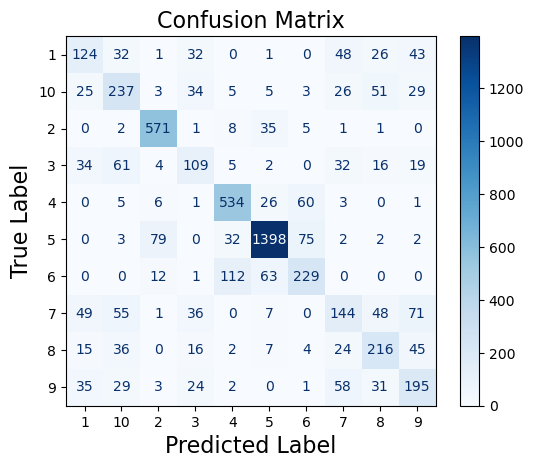

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ["1","10","2","3","4","5","6","7","8","9"]

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(20, 16))  # Set the figure size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.show()

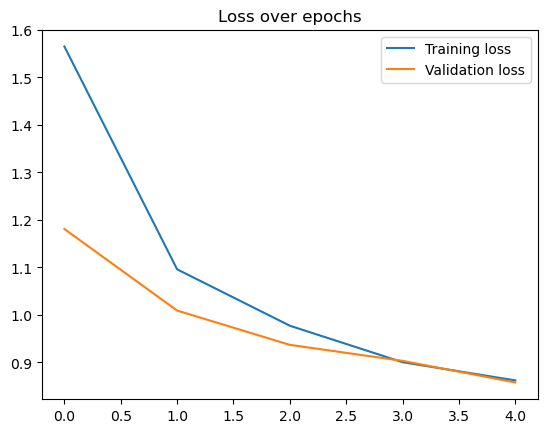

In [6]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

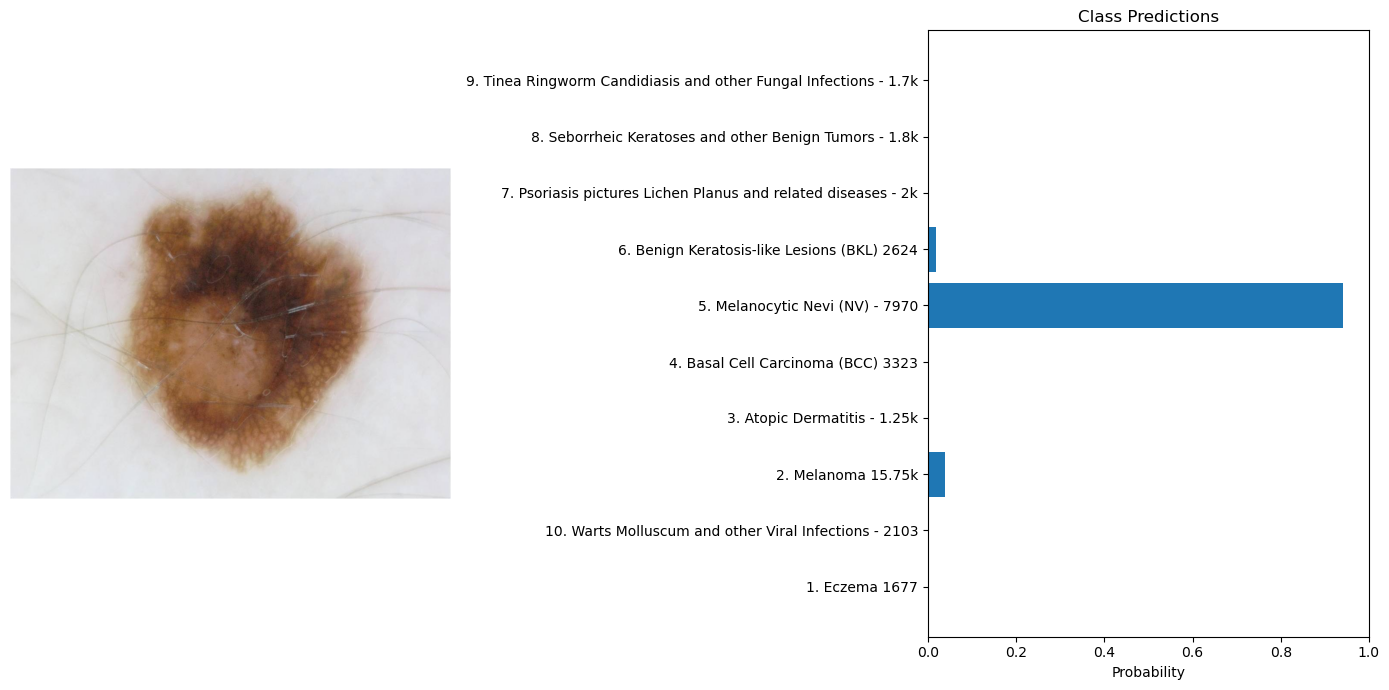

In [7]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model1 (YOUR REAL MODEL)
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    axarr[0].imshow(original_image)
    axarr[0].axis("off")

    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Test image path
test_image = "/Users/youshodeepacharya/Downloads/IMG_CLASSES/5. Melanocytic Nevi (NV) - 7970/ISIC_0000003.jpg"

# Transform must match training transform
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Load + preprocess
original_image, image_tensor = preprocess_image(test_image, transform)

# 🔥 USE model1 (your trained EfficientNet-B0)
probabilities = predict(model1, image_tensor, device)

# Class names from dataset
class_names = dataset.classes

visualize_predictions(original_image, probabilities, class_names)